# Full pipeline execution code

## Multimodal Retrieval Pipeline (Image + Caption Embedding with Milvus)

### **Overall Workflow**
1. **Image Captioning** → Generate descriptive captions using **Florence-2-base**  
2. **Embedding Generation**  
   - **Image Embedding:** `CLIP-ViT-B-32`  
   - **Caption Embedding:** `all-MiniLM-L6-v2`  
3. **Vector Storage** → Store both embeddings in **Milvus**  
4. **Re-ranking** → Combine retrieval results using weighted similarity (Late Fusion)

1. **Image Captioning**
- Florence-2-base

In [ ]:
# !pip install --no-cache-dir einops timm
#!pip install -r requirements.txt --upgrade

In [ ]:
# import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [1]:
import sys
sys.path.append("/Users/kimsejung/Model/5.milvus/milvus_clip_llm_rag")

In [3]:
from captioning.captioning import FlorenceCaptioner

if __name__ == "__main__":
    captioner = FlorenceCaptioner()
    captioner.load_model()

    # you can dynamically define your prompt
    prompt = "<DETAILED_CAPTION>"

    captioner.generate_captions(
        image_folder="./images_folder/train",
        output_csv="./caption.csv",
        prompt=prompt
    )

Using device: mps
Loading microsoft/Florence-2-base...
✅ Model loaded successfully on [mps]
1005 images → start captioning


Captioning: 100%|███████████████████████████| 1005/1005 [10:54<00:00,  1.54it/s]


✅ Completed! 1005 captions saved → ./caption.csv


2. **Embedding Generation**
   - **Image Embedding:** `CLIP-ViT-B-32`  
   - **Caption Embedding:** `all-MiniLM-L6-v2`

In [3]:
from pymilvus import MilvusClient, DataType
from embedding.encoder import ImageTextEmbedder

# Milvus 연결
client = MilvusClient(uri="http://localhost:19530")

# 컬렉션 이름
collection_name = "florence_clip_miniLM"

# 스키마 생성
schema = client.create_schema(auto_id=False, enable_dynamic_field=True)

# 필드 정의 (ImageTextEmbedder 구조에 맞게)
schema.add_field("id", DataType.INT64, is_primary=True)
schema.add_field("vector_clip_image", DataType.FLOAT_VECTOR, dim=512)   # CLIP 이미지 임베딩
schema.add_field("vector_clip_text", DataType.FLOAT_VECTOR, dim=384)    # MiniLM 텍스트 임베딩
schema.add_field("caption", DataType.VARCHAR, max_length=1000)          # 캡션 텍스트
schema.add_field("filepath", DataType.VARCHAR, max_length=512)          # 이미지 경로
schema.add_field("metadata", DataType.VARCHAR, max_length=512)          # 메타데이터 (옵션)
schema.add_field("created_at", DataType.VARCHAR, max_length=32)         # 생성 시간 (옵션)

# 인덱스 파라미터 설정
index_params = client.prepare_index_params()
index_params.add_index(
    field_name="vector_clip_image",
    index_type="IVF_FLAT",
    metric_type="IP",
    params={"nlist": 128}
)
index_params.add_index(
    field_name="vector_clip_text",
    index_type="IVF_FLAT",
    metric_type="IP",
    params={"nlist": 128}
)

# 컬렉션 생성
client.create_collection(
    collection_name=collection_name,
    schema=schema,
    index_params=index_params
)

print(f" Created collection for ImageTextEmbedder: {collection_name}")


 Created collection for ImageTextEmbedder: florence_clip_miniLM


In [7]:
from datetime import datetime
import json, os
import pandas as pd
from tqdm import tqdm

from embedding.encoder import ImageTextEmbedder


csv_path = "./caption.csv"   # FlorenceCaptioner가 생성한 CSV 파일
collection_name = "florence_clip_miniLM"

data_to_insert = []
id_counter = 1


# ImageTextEmbedder 클래스 인스턴스 생성 (임베딩 전용)

encoder = ImageTextEmbedder() 

df = pd.read_csv(csv_path)
print(f" Loaded {len(df)} captions from {csv_path}")


# CSV의 image_path + caption 기반으로 임베딩 생성
for _, row in tqdm(df.iterrows(), total=len(df), desc="Embedding captions"):
    path = row["image_path"]
    caption = row["caption"]
    created_time = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")

    # 이미지 임베딩 (512차원)
    img_vec = encoder._embed_image(path)

    # 캡션 텍스트 임베딩 (384차원)
    text_vec = encoder._embed_text(caption)

    if img_vec is None or text_vec is None:
        continue

    data_to_insert.append({
        "id": id_counter,
        "vector_clip_image": img_vec.tolist(),
        "vector_clip_text": text_vec.tolist(),
        "caption": caption,
        "filepath": path,
        "metadata": json.dumps({"source": "caption_csv"}),
        "created_at": created_time
    })
    id_counter += 1


client.insert(collection_name=collection_name, data=data_to_insert)
print(f" Inserted {len(data_to_insert)} caption-based entries into '{collection_name}'")


 Using device: cpu
 Loading embedding models...
 Models loaded successfully.
 Loaded 1005 captions from ./caption.csv


Embedding captions: 100%|███████████████████| 1005/1005 [00:35<00:00, 28.04it/s]

 Inserted 1005 caption-based entries into 'florence_clip_miniLM'


3. **chatbot 생성**
- LangChain RAG 생성
- "사람이 등장하는 이미지는 총 몇장이지? 그리고 해당하는 이미지 1개만 보여줘"

In [19]:
import os

env_path = ".env"

if not os.path.exists(env_path):
    key = input(" Enter your OpenAI API Key (starts with sk-): ").strip()
    with open(env_path, "w") as f:
        f.write(f"OPENAI_API_KEY={key}\n")
    print(f" .env file created successfully at {os.path.abspath(env_path)}")
else:
    print(" .env file already exists!")

 .env file already exists!


- llm으로 넘기는 문서를 제안하지 않을 경우 토큰 한도 초과

- 벡터DB caption 필드 검색엔진

In [27]:
import json
import os
from pymilvus import MilvusClient
from PIL import Image
from IPython.display import display

from langchain_openai import ChatOpenAI
from embedding.encoder import ImageTextEmbedder  


class MilvusFlorenceRAG:
    def __init__(self,
                 milvus_uri="http://localhost:19530",
                 collection_name="florence_clip_miniLM",
                 llm_model="gpt-4o-mini"):

        self.collection_name = collection_name
        self.client = MilvusClient(uri=milvus_uri)
        self.encoder = ImageTextEmbedder()
        self.llm = ChatOpenAI(model=llm_model, temperature=0.0)


    # 텍스트 기반 Milvus 검색
    def milvus_search_by_text(self, query_text, top_k=5):
        query_vec = self.encoder._embed_text(query_text)
    
        results = self.client.search(
            collection_name=self.collection_name,
            data=[query_vec],
            anns_field="vector_clip_text",
            limit=top_k,
            output_fields=["filepath", "caption"]
        )
    
        hits = []
        for hit in results[0]:
            similarity = 1 / (1 + hit["distance"])
    
            hits.append({
                "filepath": hit["entity"]["filepath"],
                "caption": hit["entity"]["caption"],
                "score": similarity,
                "raw_distance": hit["distance"]
            })
    
        return hits

    # LLM에게 답변 생성
    def answer(self, query, search_results):
        context = "\n".join(
            [f"- {item['caption']} (path: {item['filepath']})" for item in search_results]
        )

        prompt = f"""
You are a vision-language assistant.
Here are the most relevant images retrieved from a vector database:

{context}

User question: "{query}"

Provide a factual answer based strictly on the retrieved image captions.
"""

        return self.llm.invoke(prompt).content


    # 최상위 이미지 보여주기
    def show_top_image(self, search_results):
        if not search_results:
            print("No image found.")
            return

        top = search_results[0]
        path = top["filepath"]

        print(f"Showing: {path}\nCaption: {top['caption']}\nScore: {top['score']}")

        img = Image.open(path).convert("RGB")
        display(img)

    # 전체 RAG 파이프라인 수행
    def query(self, user_query, top_k=5):

        search_results = self.milvus_search_by_text(user_query, top_k=top_k)
        answer = self.answer(user_query, search_results)
        self.show_top_image(search_results)

        return answer


 Using device: cpu
 Loading embedding models...
 Models loaded successfully.
Showing: images_folder/train/jean/n03594734_24159.JPEG
Caption: The image shows a woman standing in front of a white wall with her arms crossed, wearing a green sweater and blue jeans, with a smile on her face.
Score: 0.80272897543841


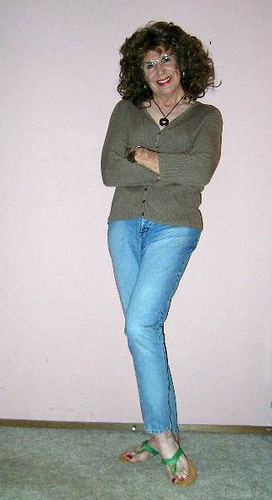

LLM Response:
 사람이 등장하는 이미지는 총 7장입니다. 그중 하나의 이미지는 다음과 같습니다:

- 이미지 설명: 한 여성이 흰색 벽 앞에 서서 팔짱을 끼고 있으며, 초록색 스웨터와 파란색 청바지를 입고 웃고 있습니다. (경로: images_folder/train/jean/n03594734_24159.JPEG)


In [29]:
rag = MilvusFlorenceRAG()

query = "사람이 등장하는 이미지는 총 몇 장이지? 그리고 그중 하나 보여줘."
response = rag.query(query, top_k=10)

print("LLM Response:\n", response)

---

- milvus 구조 확인
- 필드 차원 확인

In [19]:
from pymilvus import MilvusClient
import pprint

client = MilvusClient(uri="http://localhost:19530")
collection_name = "florence_clip_miniLM"
info = client.describe_collection(collection_name)

print("\n=== Collection Schema ===")
pprint.pprint(info)



=== Collection Schema ===
{'aliases': [],
 'auto_id': False,
 'collection_id': 461933638312519682,
 'collection_name': 'florence_clip_miniLM',
 'consistency_level': 2,
 'created_timestamp': 461982204689121287,
 'description': '',
 'enable_dynamic_field': True,
 'fields': [{'description': '',
             'field_id': 100,
             'is_primary': True,
             'name': 'id',
             'params': {},
             'type': <DataType.INT64: 5>},
            {'description': '',
             'field_id': 101,
             'name': 'vector_clip_image',
             'params': {'dim': 512},
             'type': <DataType.FLOAT_VECTOR: 101>},
            {'description': '',
             'field_id': 102,
             'name': 'vector_clip_text',
             'params': {'dim': 384},
             'type': <DataType.FLOAT_VECTOR: 101>},
            {'description': '',
             'field_id': 103,
             'name': 'caption',
             'params': {'max_length': 1000},
             'type': <

In [25]:
from pymilvus import MilvusClient
import pprint

client = MilvusClient(uri="http://localhost:19530")
collection_name = "florence_clip_miniLM"


schema = client.describe_collection(collection_name)
fields = schema["fields"]


text_dim = None
for f in fields:
    if f["name"] == "vector_clip_text":
        text_dim = f["params"]["dim"]

print("Detected text vector dimension:", text_dim)


dummy_vec = [0.0] * text_dim  # = 384

res = client.search(
    collection_name=collection_name,
    data=[dummy_vec],
    anns_field="vector_clip_text",
    limit=3,
    output_fields=["filepath", "caption"]
)

print("\n=== Raw Search Result ===")
pprint.pprint(res)


Detected text vector dimension: 384

=== Raw Search Result ===
data: [[{'id': 3, 'distance': 0.0, 'entity': {'filepath': 'images_folder/train/mixing_bowl/n03775546_17054.JPEG', 'caption': 'The image shows a kitchen counter with a bowl sitting on top of it. In the background, there is a stove, cupboards, and a wall. On the counter, there are a few other objects.'}}, {'id': 2, 'distance': 0.0, 'entity': {'filepath': 'images_folder/train/mixing_bowl/n03775546_2583.JPEG', 'caption': 'The image shows a green bowl sitting on top of a carpeted floor, with a wall in the background. The bowl is a vibrant green color, and the carpet is a neutral color.'}}, {'id': 1, 'distance': 0.0, 'entity': {'filepath': 'images_folder/train/mixing_bowl/n03775546_1526.JPEG', 'caption': 'The image shows a blue bowl filled with dough sitting on top of a wooden table. The bowl is filled to the brim with the dough, and there are a few other objects scattered around the table.'}}]]
